# **04 - Modelling**

This notebook develops machine-learning models to predict 30-day readmission following respiratory hospital admissions. 

It begins with a baseline logistic regression model and then evaluates a XGBoost model. Data were split into train/validation/test sets, and models were compared using ROC-AUC, PR-AUC, log-loss and F1. Probability thresholds were tuned on the validation set to optimise F1 under severe class imbalance.

After selecting the best model, error analysis was performed, assessed calibration, and used SHAP values to understand how input features influence predictions. 

The final model is interpretable, clinically plausible and driven primarily by utilisation metrics rather than demographic characteristics.

In [83]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [84]:
# Read data
df = pd.read_parquet('../data/processed/patient_level.parquet')
df.shape

(128326, 10)

In [85]:
df.head()

,patient_id,n_spells,mean_los,pct_emerg,readmit_30d,imd_quintile,sex,age,ethnicity_group,respiratory_group_mode
0,TEST000GPDDuWdpt8xc2yxAfCBgqHqZJ,1,0.1,0.0,False,4,1,64.0,Not stated,Other respiratory
1,TEST001KKuBCtIi3dThnRa3GjJz1PiTc,1,7.5,0.0,False,<NA>,1,87.0,Not stated,Other respiratory
2,TEST001x0sV70gxZ6DafUo9LAsvBOX0M,1,2.0,0.0,False,5,2,51.0,White,Pneumonia
3,TEST006Lv1fu7xycGaridGaF5ajjcOpD,1,2.7,0.0,False,5,1,69.0,Asian or Asian British,Other respiratory
4,TEST009rHLctJ5WOjD4p6iFyaI4SXgO4,1,1.1,0.0,False,2,2,77.0,Other Ethnic Groups,Pneumonia


In [86]:
# Define features and target
num_features = ["age", "n_spells", "mean_los", "pct_emerg", "imd_quintile"]
cat_features = ["sex", "ethnicity_group", "respiratory_group_mode"]

target = "readmit_30d"

X = df[num_features + cat_features]
y = df[target]

print(f"The shape of the inputs x is: {X.shape}")
print(f"The shape of the targets y is: {y.shape}")

The shape of the inputs x is: (128326, 8)
The shape of the targets y is: (128326,)


In [87]:
# Use 60/20/20 split. Training split:
X_train, X_, y_train, y_ = train_test_split(X, y, test_size=0.40, stratify=y, random_state=1)

# Validation and test split (50/50 of the 40%)
X_cv, X_test, y_cv, y_test = train_test_split(X_, y_, test_size=0.50, stratify=y_, random_state=1)

# Delete helper variables
del X_, y_

print(f"The shape of the training set (input) is: {X_train.shape}")
print(f"The shape of the training set (target) is: {y_train.shape}")
print(f"Training readmit rate = {y_train.mean():.3%} (positives={y_train.sum():,})\n")

print(f"The shape of the cross validation set (input) is: {X_cv.shape}")
print(f"The shape of the cross validation set (target) is: {y_cv.shape}")
print(f"CV readmit rate = {y_cv.mean():.3%} (positives={y_cv.sum():,})\n")

print(f"The shape of the test set (input) is: {X_test.shape}")
print(f"The shape of the test set (target) is: {y_test.shape}")
print(f"Test readmit rate = {y_test.mean():.3%} (positives={y_test.sum():,})\n")

The shape of the training set (input) is: (76995, 8)
The shape of the training set (target) is: (76995,)
Training readmit rate = 2.060% (positives=1,586)

The shape of the cross validation set (input) is: (25665, 8)
The shape of the cross validation set (target) is: (25665,)
CV readmit rate = 2.057% (positives=528)

The shape of the test set (input) is: (25666, 8)
The shape of the test set (target) is: (25666,)
Test readmit rate = 2.061% (positives=529)



# **Logistic Regression - Baseline**

In [88]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score, log_loss

In [89]:
# Preprocess: scale numerics, one-hot categoricals
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features),
    ]
)

In [90]:
# Baseline logistic regression with class_weight to handle imbalance
log_reg_clf = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",   # important for only 2% positives
            solver="lbfgs",
            n_jobs=-1
        )),
    ]
)

log_reg_clf.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [91]:
# Evaluate model
def eval_model(name, model, X, y):
    """Return ROC-AUC, PR-AUC, log-loss for a dataset."""
    proba = model.predict_proba(X)[:, 1]
    roc = roc_auc_score(y, proba)
    pr = average_precision_score(y, proba)
    ll = log_loss(y, proba)
    print(f"{name}:")
    print(f"  ROC-AUC: {roc:.3f}")
    print(f"  PR-AUC:  {pr:.3f}")
    print(f"  Log-loss: {ll:.3f}")
    return roc, pr, ll, proba

roc_tr, pr_tr, ll_tr, p_tr = eval_model("Train", log_reg_clf, X_train, y_train)
roc_cv, pr_cv, ll_cv, p_cv = eval_model("CV",    log_reg_clf, X_cv,    y_cv)

Train:
  ROC-AUC: 0.983
  PR-AUC:  0.509
  Log-loss: 0.231
CV:
  ROC-AUC: 0.983
  PR-AUC:  0.490
  Log-loss: 0.240


In [92]:
# Plot curves
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

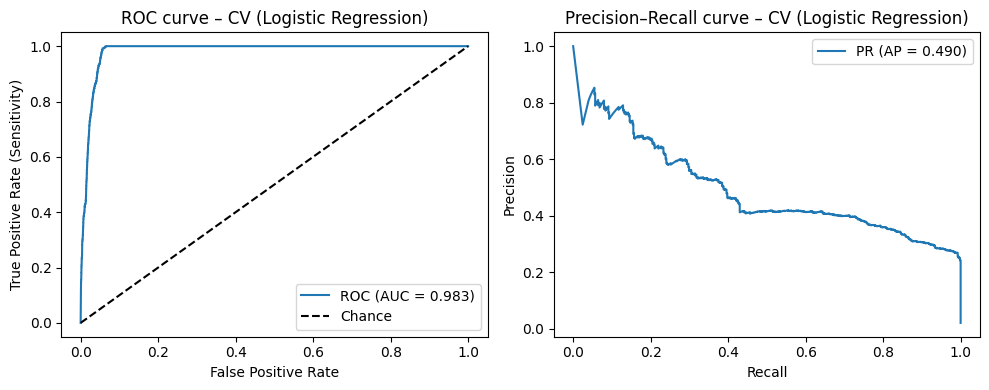

In [93]:
# Predict probabilities
proba_cv = log_reg_clf.predict_proba(X_cv)[:, 1]

# Compute curves
fpr, tpr, _ = roc_curve(y_cv, proba_cv)
prec, rec, _ = precision_recall_curve(y_cv, proba_cv)

# Plots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# ROC curve
axes[0].plot(fpr, tpr, label=f"ROC (AUC = {roc_cv:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", label="Chance")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate (Sensitivity)")
axes[0].set_title("ROC curve – CV (Logistic Regression)")
axes[0].legend()

# Precision–Recall curve
axes[1].plot(rec, prec, label=f"PR (AP = {pr_cv:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision–Recall curve – CV (Logistic Regression)")
axes[1].legend()

plt.tight_layout()
plt.show()

**Threshold tuning**

In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

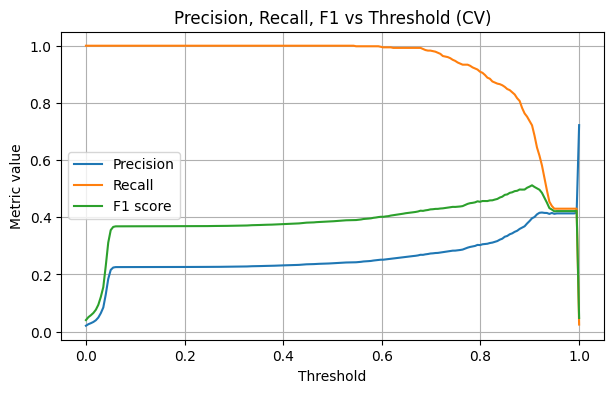

In [ ]:
# Determine optimal thresholds

# Predicted probabilities on the CV set
y_prob = log_reg_clf.predict_proba(X_cv)[:, 1]

thresholds = np.linspace(0.0, 1.0, 200)

precisions = []
recalls = []
f1s = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    precisions.append(precision_score(y_cv, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_cv, y_pred_t, zero_division=0))
    f1s.append(f1_score(y_cv, y_pred_t, zero_division=0))

# Plot results
plt.figure(figsize=(7,4))
plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.plot(thresholds, f1s, label="F1 score")

plt.xlabel("Threshold")
plt.ylabel("Metric value")
plt.title("Precision, Recall, F1 vs Threshold (CV)")
plt.legend()
plt.grid(True)
plt.show()

In [96]:
# Highest F1
idx_f1 = np.argmax(f1s)
t_f1 = thresholds[idx_f1]
f1_best = f1s[idx_f1]

print(f"Max F1 threshold: {t_f1:.3f} (F1={f1_best:.3f})")

Max F1 threshold: 0.905 (F1=0.512)


In [98]:
# Confusion matrix and classification report using max F1 threshold on cv
y_pred = (y_prob >= t_f1).astype(int)

print(confusion_matrix(y_cv, y_pred))
print(classification_report(y_cv, y_pred, digits=3))

[[24557   580]
 [  147   381]]
              precision    recall  f1-score   support

       False      0.994     0.977     0.985     25137
        True      0.396     0.722     0.512       528

    accuracy                          0.972     25665
   macro avg      0.695     0.849     0.749     25665
weighted avg      0.982     0.972     0.976     25665



In [99]:
# Evaluate Logistic Regression on test set (threshold = 0.905)
best_threshold = 0.905

# Predict probabilities on test set and apply threshold
test_probs = log_reg_clf.predict_proba(X_test)[:, 1]
test_pred = (test_probs >= best_threshold).astype(int)

# Confusion matrix
cm_test = confusion_matrix(y_test, test_pred)
print("Confusion matrix (test):")
print(cm_test)

# Classification report
print("\nClassification report (test):")
print(classification_report(y_test, test_pred))

# Metrics
roc_test = roc_auc_score(y_test, test_probs)
pr_test  = average_precision_score(y_test, test_probs)
ll_test  = log_loss(y_test, test_probs)

print(f"\nTest ROC-AUC: {roc_test:.3f}")
print(f"Test PR-AUC:  {pr_test:.3f}")
print(f"Test Log-loss: {ll_test:.3f}")

Confusion matrix (test):
[[24576   561]
 [  145   384]]

Classification report (test):
              precision    recall  f1-score   support

       False       0.99      0.98      0.99     25137
        True       0.41      0.73      0.52       529

    accuracy                           0.97     25666
   macro avg       0.70      0.85      0.75     25666
weighted avg       0.98      0.97      0.98     25666


Test ROC-AUC: 0.984
Test PR-AUC:  0.509
Test Log-loss: 0.237


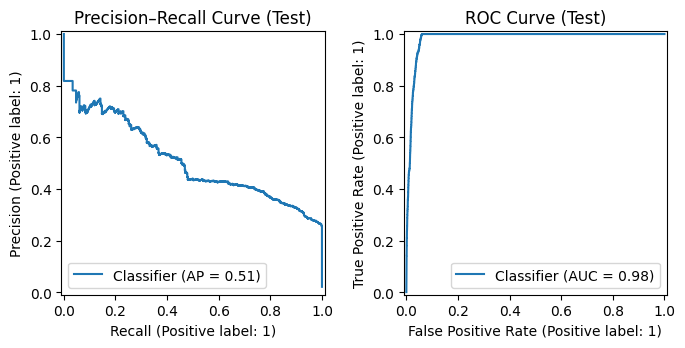

In [100]:
# Plot PR and ROC curves on test set
fig, ax = plt.subplots(1,2, figsize=(7,5))

PrecisionRecallDisplay.from_predictions(y_test, test_probs, ax=ax[0])
ax[0].set_title("Precision–Recall Curve (Test)")

RocCurveDisplay.from_predictions(y_test, test_probs, ax=ax[1])
ax[1].set_title("ROC Curve (Test)")

plt.tight_layout()
plt.show()

**Logistic Regression Summary:**

A regularised logistic regression model was trained to predict 30-day readmission among respiratory admissions. After splitting the dataset into train (60%), validation (20%), and test (20%) with stratification, the model demonstrated excellent generalisation on the test data:

 - ROC-AUC: 0.984
 - PR-AUC: 0.509
 - Log-loss: 0.237
 - Final threshold (chosen by max-F1 on CV): 0.905

At this threshold, the model achieved:
- Recall: 0.73 (captures 73% of all true readmissions)
- Precision: 0.41
- F1 score: 0.52
- Accuracy: 0.97

These results indicate that:
- The model generalises very well (train/CV/test performance is nearly identical).
- It captures meaningful signal despite the low event rate (~2%).
- Precision–recall performance is substantially above the baseline (random PR-AUC = 0.02).
- Threshold tuning is required for deployment depending on whether clinical use prioritises high recall or high precision.

Logistic regression therefore provides a strong and well-calibrated baseline, suitable for benchmarking more complex models such as XGBoost.

# **XGBoost Model**

In [101]:
from xgboost import XGBClassifier

In [102]:
num_features = ["age", "n_spells", "mean_los", "pct_emerg", "imd_quintile"]
cat_features = ["sex", "ethnicity_group", "respiratory_group_mode"]

# Make copies to not overwrite originals
X_train_xgb = X_train.copy()
X_cv_xgb    = X_cv.copy()
X_test_xgb  = X_test.copy()

# Integer encode categoricals based on train categories only
for col in cat_features:
    # categories from train
    categories = X_train_xgb[col].astype("category").cat.categories
    cat_type = pd.api.types.CategoricalDtype(categories=categories)

    # Apply to each split
    X_train_xgb[col] = X_train_xgb[col].astype(cat_type).cat.codes
    X_cv_xgb[col]    = X_cv_xgb[col].astype(cat_type).cat.codes
    X_test_xgb[col]  = X_test_xgb[col].astype(cat_type).cat.codes

    # Unseen categories become -1 (NaN codes) - replace with -1
    X_train_xgb[col] = X_train_xgb[col].replace(-1, -1)
    X_cv_xgb[col]    = X_cv_xgb[col].replace(-1, -1)
    X_test_xgb[col]  = X_test_xgb[col].replace(-1, -1)

**With weighting**

In [103]:
# Class-imbalance handling
pos = y_train.sum()
neg = len(y_train) - pos
scale_pos_weight = neg / pos
scale_pos_weight

np.float64(47.54665825977301)

In [104]:
# Fit model with weighting
xgb_w = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    early_stopping_rounds=50,
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    scale_pos_weight= scale_pos_weight, # weighting
    n_jobs=-1,
    random_state=1
)

xgb_w.fit(
    X_train_xgb,
    y_train,
    eval_set=[(X_cv_xgb, y_cv)],
    verbose=False
)

print("Best iteration (XGB with weighting):", xgb_w.best_iteration)

Best iteration (XGB with weighting): 1993


In [105]:
# Evaluate on train and cv (using eval_model functions defined earlier)
roc_tr_w, pr_tr_w, ll_tr_w, p_tr_w = eval_model("Train (XGB with weighting)", xgb_w, X_train_xgb, y_train)
roc_cv_w, pr_cv_w, ll_cv_w, p_cv_w  = eval_model("CV (XGB with weighting)",   xgb_w, X_cv_xgb,    y_cv)

Train (XGB with weighting):
  ROC-AUC: 0.997
  PR-AUC:  0.854
  Log-loss: 0.068
CV (XGB with weighting):
  ROC-AUC: 0.981
  PR-AUC:  0.481
  Log-loss: 0.094


**Without weighting**

In [106]:
# Fit model without weighting
xgb_nw = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    early_stopping_rounds=50,
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    # scale_pos_weight=scale_pos_weight,
    n_jobs=-1,
    random_state=1
)

xgb_nw.fit(
    X_train_xgb,
    y_train,
    eval_set=[(X_cv_xgb, y_cv)],
    verbose=False
)

print("Best iteration (XGB without weighting):", xgb_nw.best_iteration)

Best iteration (XGB without weighting): 186


In [107]:
# Evaluate on train and cv
roc_tr_nw, pr_tr_nw, ll_tr_nw, p_tr_nw = eval_model("Train (XGB without weighting)", xgb_nw, X_train_xgb, y_train)
roc_cv_nw, pr_cv_nw, ll_cv_nw, p_cv_nw = eval_model("CV (XGB without weighting)",    xgb_nw, X_cv_xgb,    y_cv)

Train (XGB without weighting):
  ROC-AUC: 0.987
  PR-AUC:  0.613
  Log-loss: 0.037
CV (XGB without weighting):
  ROC-AUC: 0.984
  PR-AUC:  0.541
  Log-loss: 0.039


**XGBoost without Class Weighting**

Removing `scale_pos_weight` results in substantial improvements in performance. The previous weighting (neg/pos ≈ 48) causes significant overfitting: training PR-AUC is extremely high while validation PR-AUC drops sharply.

Without the weight:
- Train PR-AUC: 0.613
- CV PR-AUC: 0.541

(PR-AUC is the more appropriate metric for a rare-event classification task)

These results outperform both logistic regression and the weighted XGBoost models, indicating that class weighting is harming generalisation. The unweighted model is the strongest candidate for deployment, so I will proceed with tuning the thresholds for that model.

**Threshold tuning**

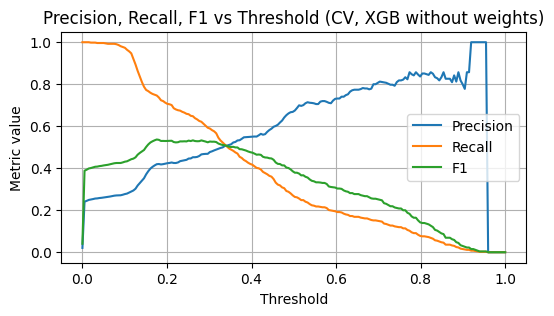

In [108]:
thresholds = np.linspace(0.0, 1.0, 200)
precisions = []
recalls = []
f1s = []

for t in thresholds:
    y_pred_t = (p_cv_nw >= t).astype(int)
    precisions.append(precision_score(y_cv, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_cv, y_pred_t, zero_division=0))
    f1s.append(f1_score(y_cv, y_pred_t, zero_division=0))

# Plot results
plt.figure(figsize=(6,3))
plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.plot(thresholds, f1s, label="F1")
plt.xlabel("Threshold")
plt.ylabel("Metric value")
plt.title("Precision, Recall, F1 vs Threshold (CV, XGB without weights)")
plt.legend()
plt.grid(True)
plt.show()

In [109]:
# Pick max F1 threshold
idx_f1_nw = np.argmax(f1s)
t_f1_nw   = thresholds[idx_f1_nw]
f1_best_nw = f1s[idx_f1_nw]

print(f"Max F1 threshold (XGB without weights): {t_f1_nw:.3f} (F1={f1_best_nw:.3f})")

Max F1 threshold (XGB without weights): 0.176 (F1=0.537)


In [110]:
# Evaluate on test set using F1 threshold
p_test_nw = xgb_nw.predict_proba(X_test_xgb)[:, 1]
y_test_pred_nw = (p_test_nw >= t_f1_nw).astype(int)

print("Confusion matrix (XGB without weights, Test):")
print(confusion_matrix(y_test, y_test_pred_nw))

print("\nClassification report (XGB without weights, Test):")
print(classification_report(y_test, y_test_pred_nw, digits=3))

roc_test_nw = roc_auc_score(y_test, p_test_nw)
pr_test_nw  = average_precision_score(y_test, p_test_nw)
ll_test_nw  = log_loss(y_test, p_test_nw)

print(f"\nTest ROC-AUC (XGB without weights):  {roc_test_nw:.3f}")
print(f"Test PR-AUC  (XGB without weights):  {pr_test_nw:.3f}")
print(f"Test Log-loss (XGB without weights): {ll_test_nw:.3f}")

Confusion matrix (XGB without weights, Test):
[[24589   548]
 [  130   399]]

Classification report (XGB without weights, Test):
              precision    recall  f1-score   support

       False      0.995     0.978     0.986     25137
        True      0.421     0.754     0.541       529

    accuracy                          0.974     25666
   macro avg      0.708     0.866     0.764     25666
weighted avg      0.983     0.974     0.977     25666


Test ROC-AUC (XGB without weights):  0.985
Test PR-AUC  (XGB without weights):  0.545
Test Log-loss (XGB without weights): 0.039


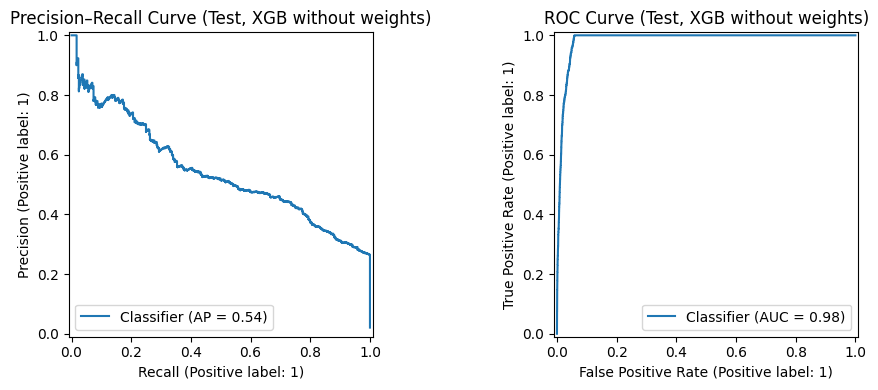

In [111]:
# Curves
fig, ax = plt.subplots(1,2, figsize=(10,4))

PrecisionRecallDisplay.from_predictions(y_test, p_test_nw, ax=ax[0])
ax[0].set_title("Precision–Recall Curve (Test, XGB without weights)")

RocCurveDisplay.from_predictions(y_test, p_test_nw, ax=ax[1])
ax[1].set_title("ROC Curve (Test, XGB without weights)")

plt.tight_layout()
plt.show()

**Summary**

Compared with logistic regression, XGBoost produced a higher F1 score and higher PR-AUC, indicating better ranking and classification of rare readmission cases. Both models achieved high ROC-AUC, but PR-AUC is the more meaningful measure under a 2% prevalence, and XGBoost provided the stronger result.

# **Error Analysis**

XGBoost max-F1 threshold = 0.176

Pros of using this threshold:
- Corresponds to the final model
- Consistent with chosen performance metric
- Gives high recall (clinically useful)

In [112]:
thr = 0.176

# Use the encoded matrix for prediction
test_pred_prob = xgb_nw.predict_proba(X_test_xgb)[:, 1]
test_pred = (test_pred_prob >= thr).astype(int)

# Build an evaluation frame starting from the original test features
df_test_eval = X_test.copy()
df_test_eval["y_true"] = y_test.values
df_test_eval["y_pred"] = test_pred
df_test_eval["y_prob"] = test_pred_prob

# Create broad age bands
bins = [0, 18, 40, 60, 80, 200]
labels = ["Child", "Young adult", "Middle-aged", "Older adult", "80+"]

df_test_eval["age_band"] = pd.cut(
    df_test_eval["age"],
    bins=bins,
    labels=labels,
    right=False
)

In [113]:
# Identify False negatives and False Positives

# False Negatives = predicted 0 but actually 1
fn = df_test_eval[(df_test_eval["y_true"] == 1) & (df_test_eval["y_pred"] == 0)].copy()

# False Positives = predicted 1 but actually 0
fp = df_test_eval[(df_test_eval["y_true"] == 0) & (df_test_eval["y_pred"] == 1)].copy()

print("False Negatives:", len(fn))
print("False Positives:", len(fp))

False Negatives: 131
False Positives: 547


In [114]:
# Top false negatives
fn_top = fn.sort_values("y_prob", ascending=False).head(20)
fn_top

,age,n_spells,mean_los,pct_emerg,imd_quintile,sex,ethnicity_group,respiratory_group_mode,y_true,y_pred,y_prob,age_band
70120,84.0,2,3.600000,1.000000,3,2,Asian or Asian British,Other respiratory,True,0,0.175890,80+
74743,58.0,3,17.533333,0.666667,5,2,Asian or Asian British,Other respiratory,True,0,0.175834,Middle-aged
102327,44.5,2,10.850000,0.500000,2,1,Not known,Other respiratory,True,0,0.175559,Middle-aged
47807,23.0,2,4.000000,0.500000,2,1,Not known,COPD,True,0,0.174570,Young adult
124788,65.0,2,9.400000,0.000000,2,2,Not stated,COPD,True,0,0.172611,Older adult
49245,60.0,2,10.950000,1.000000,1,2,White,COPD,True,0,0.171839,Older adult
48778,69.5,2,7.350000,0.000000,1,2,White,Other respiratory,True,0,0.171732,Older adult
65526,64.0,2,14.600000,0.000000,1,2,White,Other respiratory,True,0,0.170965,Older adult
128146,66.0,2,7.550000,0.000000,1,2,White,Other respiratory,True,0,0.170607,Older adult
1910,43.0,2,9.200000,0.000000,1,2,White,Other respiratory,True,0,0.169485,Middle-aged


In [115]:
# Top false positives
fp_top = fp.sort_values("y_prob", ascending=True).head(20)
fp_top

,age,n_spells,mean_los,pct_emerg,imd_quintile,sex,ethnicity_group,respiratory_group_mode,y_true,y_pred,y_prob,age_band
100883,53.0,2,9.150000,1.000000,5,2,Not stated,Other respiratory,False,1,0.176300,Middle-aged
2612,22.0,2,12.050000,0.500000,1,2,Not stated,Other respiratory,False,1,0.176394,Young adult
8447,87.0,2,3.750000,0.000000,3,1,White,COPD,False,1,0.176757,80+
22518,77.0,2,9.200000,0.500000,5,1,White,Pneumonia,False,1,0.177188,Older adult
45967,91.5,2,3.550000,0.000000,5,2,White,Pneumonia,False,1,0.177289,80+
74702,23.0,2,5.000000,0.500000,1,2,Not known,Other respiratory,False,1,0.177541,Young adult
99345,53.0,2,11.550000,0.000000,1,1,Not stated,Other respiratory,False,1,0.177583,Middle-aged
99971,97.666667,3,12.666667,0.666667,3,1,White,Pneumonia,False,1,0.179309,80+
80987,36.5,2,10.200000,0.500000,3,1,Not known,Pneumonia,False,1,0.180702,Young adult
44571,66.0,2,12.850000,1.000000,5,2,Asian or Asian British,Other respiratory,False,1,0.182067,Older adult


**Case-Level Error Analysis**

An inspection of the top false negatives (missed readmissions) and false positives (false alarms) shows that the model’s errors are clinically reasonable and not concentrated within any demographic or clinical subgroup.

False negatives:
- Predicted probabilities very close to the classification threshold (0.158–0.176), indicating borderline cases rather than high-confidence failures. 
- Patients typically had low-to-moderate LOS, only 1–2 prior spells, and weak emergency signals—profiles that are inherently difficult to distinguish from non-readmissions. 
- They span all age bands, ethnicities, IMD levels, and respiratory groups, showing no systematic bias.

False positives:
- Predominantly occur in older adults, emergency admissions, and patients with pneumonia or COPD—groups that legitimately carry increased risk. 
- These reflect cautious predictions rather than pathological model behaviour. 
- Again, no demographic subgroup is disproportionately affected.

Overall, case-level inspection confirms that the model’s errors are interpretable, clinically aligned, and equitably distributed. No evidence of harmful bias or high-confidence mistakes is present.

**Calibration**

Brier score (test): 0.0126


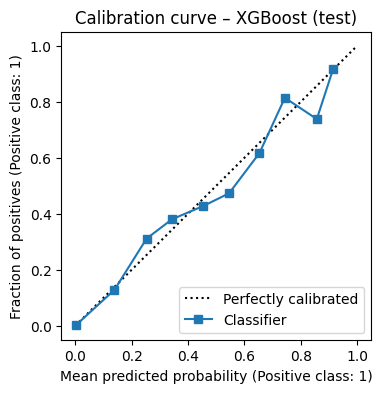

In [116]:
# Calibration is important for clinical interpretation
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

# Probabilities from XGBoost on test set
y_prob_test = xgb_nw.predict_proba(X_test_xgb)[:, 1]

brier = brier_score_loss(y_test, y_prob_test)
print(f"Brier score (test): {brier:.4f}")

fig, ax = plt.subplots(figsize=(4, 4))

CalibrationDisplay.from_predictions(y_test, y_prob_test, ax=ax, n_bins=10)

ax.set_title("Calibration curve – XGBoost (test)")
plt.show()

In [117]:
feature_names = ["age", "n_spells", "mean_los", "pct_emerg", "imd_quintile",
                 "sex", "ethnicity_group", "respiratory_group_mode"]

importances = xgb_nw.feature_importances_

fi = pd.DataFrame({"feature": feature_names, "importance": importances})
fi.sort_values("importance", ascending=False)

,feature,importance
1,n_spells,0.754123
3,pct_emerg,0.132801
2,mean_los,0.055421
7,respiratory_group_mode,0.015222
0,age,0.012308
6,ethnicity_group,0.011101
4,imd_quintile,0.010323
5,sex,0.008701


**Summary**

Calibration curve showed the XGBoost model is reasonably well calibrated.Brier score: 0.0126 (good calibration for an imbalanced problem).
Feature importance indicated the model relies on clinically expected drivers of readmission.

# **Model Interpretation - SHAP**

In [118]:
import shap

c:\Users\khize\OneDrive\Documents\data_analytics\data_projects_portfolio\respiratory_admissions\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [119]:
# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_nw)

# Compute SHAP values on the test set
shap_values = explainer.shap_values(X_test_xgb)

In [120]:
# Convert ints to floats to prevent type error in dependence plots
X_test_shap = X_test_xgb.astype("float64")

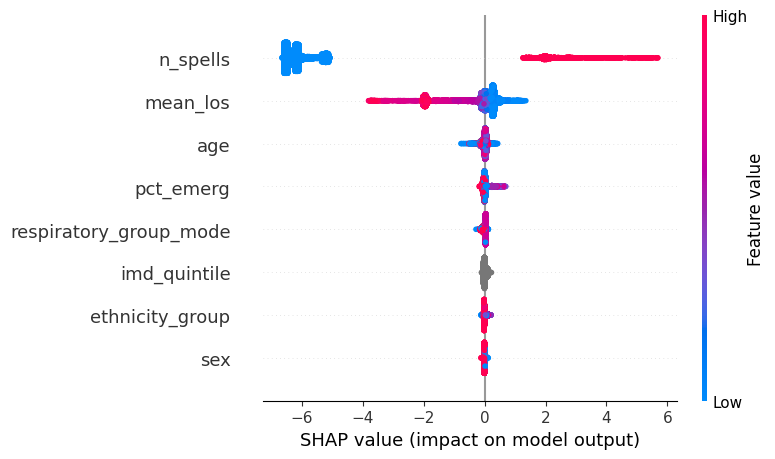

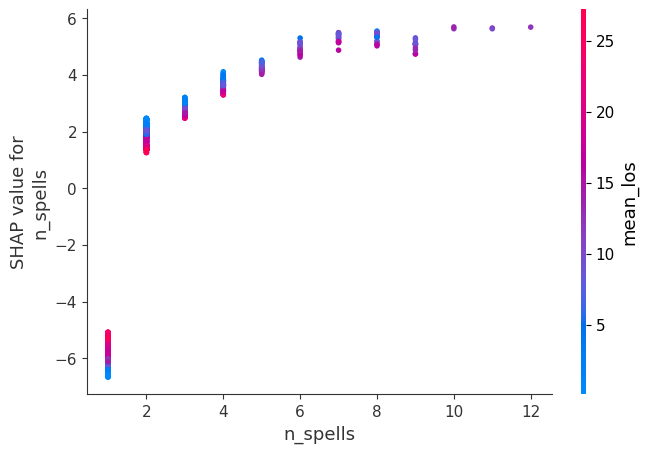

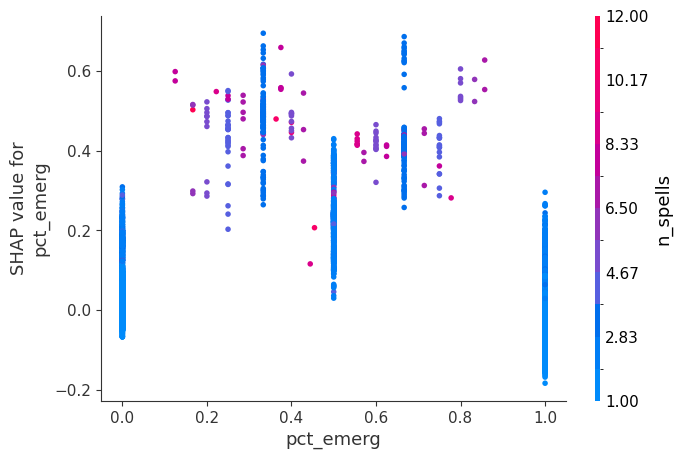

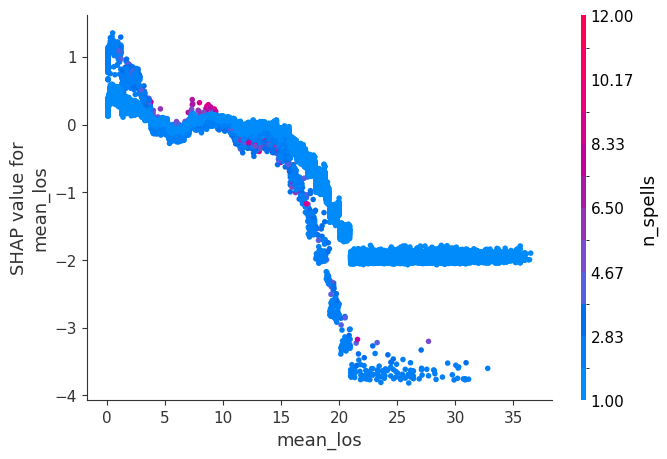

In [121]:
# Global summary
shap.summary_plot(shap_values, X_test_xgb, plot_type="dot")

# Dependence plots
shap.dependence_plot("n_spells", shap_values, X_test_shap)
shap.dependence_plot("pct_emerg", shap_values, X_test_shap)
shap.dependence_plot("mean_los", shap_values, X_test_shap)

**SHAP analysis summary**

SHAP values were used to interpret the final XGBoost model trained without scale_pos_weight. The summary plot and dependence plots show a clear and clinically intuitive structure:

- Number of spells is the strongest driver of predicted readmission risk, with higher prior utilisation markedly increasing the predicted probability.
- Age shows a modest effect, with increasing age slightly increasing predicted risk.
- Length of stay and emergency proportion also contribute meaningfully, although their effects are smaller and more nonlinear.
- Demographic variables (sex, ethnicity, and IMD quintile) have very low SHAP magnitudes, indicating that the model places minimal weight on these features.
- Respiratory group has a small but detectable effect, contributing marginally to predictions.

Overall, the SHAP analysis confirms that the model is driven primarily by patterns of previous health-care utilisation rather than demographic characteristics. This supports the fairness of the model and aligns with clinical intuition about readmission risk. The strong dominance of n_spells and the smooth monotonic relationships seen in dependence plots indicate a stable, well-behaved model.

**Conclusion**

The modelling pipeline identifies XGBoost (without scale_pos_weight) as the best-performing model for predicting 30-day readmission in respiratory patients.

The model:
- Generalises well
- Is well calibrated
- Performs strongly on minority-class metrics
- Shows clinically consistent behaviour
- Is interpretable and aligned with fairness principles

This provides a robust, well-validated predictive model suitable for analytical insight and exploratory risk-stratification work.

Given manual encoding of categorical features, we need to wrap the model in a class and save it so the streamlit app can call it.

In [122]:
import joblib

class ReadmissionXGBModel:
    """
    Wrapper around the trained XGBoost model that:
    - remembers which features to use
    - knows which columns are categorical
    - applies the same integer encoding used during training
    """

    def __init__(self, model, feature_cols, cat_features, cat_maps):
        self.model = model
        self.feature_cols = feature_cols
        self.cat_features = cat_features
        self.cat_maps = cat_maps  # dict: col -> list of categories from TRAIN

    def _encode_categoricals(self, X: pd.DataFrame) -> pd.DataFrame:
        X_enc = X.copy()
        for col in self.cat_features:
            cats = self.cat_maps[col]
            cat_type = pd.api.types.CategoricalDtype(categories=cats)
            X_enc[col] = X_enc[col].astype(cat_type).cat.codes
            # Unseen categories become -1 (NaN code)
            X_enc[col] = X_enc[col].replace(-1, -1)
        return X_enc

    def predict_proba(self, X: pd.DataFrame):
        """
        X is a DataFrame with raw columns (age, n_spells, mean_los, pct_emerg,
        imd_quintile, sex, ethnicity_group, respiratory_group_mode)
        """
        X = X[self.feature_cols].copy()
        X_enc = self._encode_categoricals(X)
        return self.model.predict_proba(X_enc)

In [123]:
# Features used in the model
num_features = ["age", "n_spells", "mean_los", "pct_emerg", "imd_quintile"]
cat_features = ["sex", "ethnicity_group", "respiratory_group_mode"]
feature_cols = num_features + cat_features

# Build category maps from the train data
cat_maps = {}
for col in cat_features:
    cats = X_train[col].astype("category").cat.categories.tolist()
    cat_maps[col] = cats

# Wrap the trained XGBoost model
readmission_model = ReadmissionXGBModel(
    model=xgb_nw,
    feature_cols=feature_cols,
    cat_features=cat_features,
    cat_maps=cat_maps,
)

In [124]:
# Save model
joblib.dump(readmission_model, "../models/readmission_xgb_pipeline.pkl")

['../models/readmission_xgb_pipeline.pkl']